# Neural Network Model

This notebook builds and evaluates our neural network model for classifying which social media platform a post belongs to.

## Goals 

This notebook follows the same split and feature policy as the earlier modeling notebooks:
- Use the saved train/validation/test parquet files from `create_datasets.ipynb`.
- Use only text-derived information.
- Exclude IDs, dates, authors, and platform-specific metadata that could leak platform identity in an unhelpful way.

## Model design

The neural network uses:

1. Sentence embeddings from `sentence-transformers/all-MiniLM-L6-v2`.
2. Engineered text statistics such as length, number of hashtags, mentions, URLs, all-caps words, etc.
3. A small MLP classifier trained with cross-entropy loss.

In [1]:
%pip install polars pyarrow pandas matplotlib scikit-learn scipy torch sentence-transformers joblib


  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 60.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 25.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 60.8 MB/s  0:00:00
Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl (3.0 MB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl (447 kB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
  Attempting uninstall: se

In [2]:
from pathlib import Path
from time import perf_counter
import random
import json
import re

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import joblib

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(14)


/Users/mhedlund/CIS2450/cis2450-final-project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


polars.config.Config

## Reproducibility

In [ ]:
# set up seeds and determinism for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Paths

In [ ]:
# Set up the input and output paths for the notebook
PROJECT_ROOT = Path.cwd().parent

TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "train_210k.parquet"
VAL_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "val_45k.parquet"
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "test_45k.parquet"

MODEL_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "modeling"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NN_OUTPUT_DIR = MODEL_OUTPUT_DIR / "neural_network"
NN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDING_CACHE_DIR = NN_OUTPUT_DIR / "embedding_cache"
EMBEDDING_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(TRAIN_PATH, TRAIN_PATH.exists())
print(VAL_PATH, VAL_PATH.exists())
print(TEST_PATH, TEST_PATH.exists())
print("Outputs will be saved to:", NN_OUTPUT_DIR)


/Users/mhedlund/CIS2450/cis2450-final-project/data/processed/final_dataset_local_duckdb/train_210k.parquet True
/Users/mhedlund/CIS2450/cis2450-final-project/data/processed/final_dataset_local_duckdb/val_45k.parquet True
/Users/mhedlund/CIS2450/cis2450-final-project/data/processed/final_dataset_local_duckdb/test_45k.parquet True
Outputs will be saved to: /Users/mhedlund/CIS2450/cis2450-final-project/outputs/modeling/neural_network


## Load train, validation, and test data

In [5]:
train_df = pl.read_parquet(TRAIN_PATH)
val_df = pl.read_parquet(VAL_PATH)
test_df = pl.read_parquet(TEST_PATH)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

train_df.head()

Train: (209999, 18)
Validation: (45000, 18)
Test: (45001, 18)


platform,post_id,author,text,created_at,likes,retweets,…,month,year_month,score,community,num_comments,upvote_ratio,parent_id
str,str,str,str,datetime[μs],f64,f64,…,i8,str,f64,str,f64,f64,str
"""hackernews""","""4380112""","""beagle3""","""> the license terms are more r…",2012-08-14 05:56:40,null,null,…,8,"""2012-08""",0.0,null,null,null,"""4380100"""
"""hackernews""","""13775458""","""simplehuman""","""You read these articles too cl…",2017-03-02 11:39:10,null,null,…,3,"""2017-03""",0.0,null,null,null,"""13775414"""
"""hackernews""","""39727388""","""toomuchtodo""","""Like <a href=""https://www.he36…",2024-03-16 12:44:56,null,null,…,3,"""2024-03""",0.0,null,null,null,"""39726890"""
"""hackernews""","""41179214""","""I_am_uncreative""","""In the English Language, ""Amer…",2024-08-07 04:02:06,null,null,…,8,"""2024-08""",0.0,null,null,null,"""41177797"""
"""hackernews""","""12680008""","""acaciapalm""","""I used the word ""show"" not ""pr…",2016-10-10 17:46:45,null,null,…,10,"""2016-10""",0.0,null,null,null,"""12679942"""


## Quick data check

The dataset was designed to be balanced across the three platforms, so accuracy is a reasonable headline metric. We will still use the full classification report and confusion matrix so we do not rely only on accuracy.

In [6]:
print("Train class counts")
print(train_df.group_by("platform").len().sort("platform"))

print("\nValidation class counts")
print(val_df.group_by("platform").len().sort("platform"))

print("\nTest class counts")
print(test_df.group_by("platform").len().sort("platform"))

Train class counts
shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 70000 │
│ reddit     ┆ 70000 │
│ twitter    ┆ 69999 │
└────────────┴───────┘

Validation class counts
shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 15000 │
│ reddit     ┆ 15000 │
│ twitter    ┆ 15000 │
└────────────┴───────┘

Test class counts
shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 15000 │
│ reddit     ┆ 15000 │
│ twitter    ┆ 15001 │
└────────────┴───────┘


## Add text statistics

Similar to the other models, we again intentionally only use text-derived features.
We reuse the same extra text statistic feature engineering from the logistic regression baseline notebook to create additional features.

In [7]:
def add_text_stats(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns([
        pl.col("text").str.count_matches(r"\?").alias("num_questions"),
        pl.col("text").str.count_matches(r"!").alias("num_exclamations"),
        pl.col("text").str.count_matches(r"#\w+").alias("num_hashtags"),
        pl.col("text").str.count_matches(r"@\w+").alias("num_mentions"),
        pl.col("text").str.count_matches(r"http[s]?://").alias("num_urls"),
        pl.col("text").str.count_matches(r"\d").alias("num_digits"),
        pl.col("text").str.count_matches(r"\b[A-Z]{2,}\b").alias("num_allcaps_words"),
        pl.col("text").str.count_matches(r"\b\w+\b").alias("num_words"),
    ]).with_columns([
        (
            pl.col("text_len") /
            pl.when(pl.col("num_words") > 0).then(pl.col("num_words")).otherwise(1)
        ).alias("avg_word_len"),
    ])

train_df = add_text_stats(train_df)
val_df = add_text_stats(val_df)
test_df = add_text_stats(test_df)

TEXT_STAT_COLS = [
    "text_len",
    "num_questions",
    "num_exclamations",
    "num_hashtags",
    "num_mentions",
    "num_urls",
    "num_digits",
    "num_allcaps_words",
    "num_words",
    "avg_word_len",
]

train_df.select(["platform", "text"] + TEXT_STAT_COLS).head()

platform,text,text_len,num_questions,num_exclamations,num_hashtags,num_mentions,num_urls,num_digits,num_allcaps_words,num_words,avg_word_len
str,str,u32,u32,u32,u32,u32,u32,u32,u32,u32,f64
"""hackernews""","""> the license terms are more r…",306,0,0,0,0,0,0,3,51,6.0
"""hackernews""","""You read these articles too cl…",77,0,0,0,0,0,0,0,14,5.5
"""hackernews""","""Like <a href=""https://www.he36…",168,1,0,0,0,2,6,0,25,6.72
"""hackernews""","""In the English Language, ""Amer…",128,0,0,0,0,0,0,1,23,5.565217
"""hackernews""","""I used the word ""show"" not ""pr…",225,0,0,0,0,0,0,0,43,5.232558


## Convert to pandas / NumPy inputs

In [9]:
train_pdf = train_df.to_pandas()
val_pdf = val_df.to_pandas()
test_pdf = test_df.to_pandas()

X_train_text = train_pdf["text"].astype(str)
X_val_text = val_pdf["text"].astype(str)
X_test_text = test_pdf["text"].astype(str)

X_train_num = train_pdf[TEXT_STAT_COLS].astype(float)
X_val_num = val_pdf[TEXT_STAT_COLS].astype(float)
X_test_num = test_pdf[TEXT_STAT_COLS].astype(float)

y_train = train_pdf["platform"].astype(str)
y_val = val_pdf["platform"].astype(str)
y_test = test_pdf["platform"].astype(str)

print("Train examples:", len(X_train_text))
print("Validation examples:", len(X_val_text))
print("Test examples:", len(X_test_text))

Train examples: 209999
Validation examples: 45000
Test examples: 45001


## Build sentence-embedding + text-stat neural-network features

Instead of feeding the neural network TF-IDF features, we encode each post with `all-MiniLM-L6-v2` sentence embeddings similar to the xgboost model to better capture semantic and stylistic similarity along witht he engineered text statistics created earlier.

In [ ]:
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_BATCH_SIZE = 256
EMBEDDING_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NORMALIZE_EMBEDDINGS = True

print("Embedding device:", EMBEDDING_DEVICE)

def encode_or_load_embeddings(texts, split_name: str) -> np.ndarray:
    """Encode text with MiniLM, caching embeddings so reruns are much faster."""
    cache_suffix = "full"
    cache_path = EMBEDDING_CACHE_DIR / f"{split_name}_minilm_l6_v2_{cache_suffix}.npy"

    if cache_path.exists():
        print(f"Loading cached {split_name} embeddings from {cache_path}")
        return np.load(cache_path)

    print(f"Encoding {split_name} text with {EMBEDDING_MODEL_NAME}...")
    t0 = perf_counter()

    embeddings = embedding_model.encode(
        texts,
        batch_size=EMBEDDING_BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=NORMALIZE_EMBEDDINGS,
    ).astype(np.float32)

    t1 = perf_counter()
    print(f"{split_name} embedding shape: {embeddings.shape}")
    print(f"{split_name} encoding time: {t1 - t0:.2f} seconds")

    np.save(cache_path, embeddings)
    print(f"Saved {split_name} embeddings to {cache_path}")

    return embeddings


print("Loading sentence embedding model...")
t0 = perf_counter()
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=EMBEDDING_DEVICE)
t1 = perf_counter()

print(f"Embedding model loaded in {t1 - t0:.2f} seconds")
print("Embedding model device:", embedding_model.device)

X_train_embed = encode_or_load_embeddings(X_train_text.tolist(), "train")
X_val_embed = encode_or_load_embeddings(X_val_text.tolist(), "val")
X_test_embed = encode_or_load_embeddings(X_test_text.tolist(), "test")

print("Embedding shapes:")
print(X_train_embed.shape, X_val_embed.shape, X_test_embed.shape)


Embedding device: cpu
Loading sentence embedding model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 15780.73it/s]


Embedding model loaded in 4.41 seconds
Embedding model device: cpu
Encoding train text with sentence-transformers/all-MiniLM-L6-v2...


Batches: 100%|██████████| 821/821 [13:29<00:00,  1.01it/s]


train embedding shape: (209999, 384)
train encoding time: 810.05 seconds
Saved train embeddings to /Users/mhedlund/CIS2450/cis2450-final-project/outputs/modeling/neural_network/embedding_cache/train_minilm_l6_v2_full.npy
Encoding val text with sentence-transformers/all-MiniLM-L6-v2...


Batches: 100%|██████████| 176/176 [02:49<00:00,  1.04it/s]


val embedding shape: (45000, 384)
val encoding time: 169.93 seconds
Saved val embeddings to /Users/mhedlund/CIS2450/cis2450-final-project/outputs/modeling/neural_network/embedding_cache/val_minilm_l6_v2_full.npy
Encoding test text with sentence-transformers/all-MiniLM-L6-v2...


Batches: 100%|██████████| 176/176 [02:50<00:00,  1.04it/s]


test embedding shape: (45001, 384)
test encoding time: 170.16 seconds
Saved test embeddings to /Users/mhedlund/CIS2450/cis2450-final-project/outputs/modeling/neural_network/embedding_cache/test_minilm_l6_v2_full.npy
Embedding shapes:
(209999, 384) (45000, 384) (45001, 384)


In [23]:
print("Scaling text-stat features")
num_scaler = StandardScaler()

X_train_num_scaled = num_scaler.fit_transform(X_train_num).astype(np.float32)
X_val_num_scaled = num_scaler.transform(X_val_num).astype(np.float32)
X_test_num_scaled = num_scaler.transform(X_test_num).astype(np.float32)

# Additionally use standard scaling 
print("Scaling embedding features")
embedding_scaler = StandardScaler()

X_train_embed_scaled = embedding_scaler.fit_transform(X_train_embed).astype(np.float32)
X_val_embed_scaled = embedding_scaler.transform(X_val_embed).astype(np.float32)
X_test_embed_scaled = embedding_scaler.transform(X_test_embed).astype(np.float32)

X_train_final = np.hstack([X_train_embed_scaled, X_train_num_scaled]).astype(np.float32)
X_val_final = np.hstack([X_val_embed_scaled, X_val_num_scaled]).astype(np.float32)
X_test_final = np.hstack([X_test_embed_scaled, X_test_num_scaled]).astype(np.float32)

print("Final dense feature shapes:")
print(X_train_final.shape, X_val_final.shape, X_test_final.shape)


Scaling text-stat features
Scaling embedding features
Final dense feature shapes:
(209999, 394) (45000, 394) (45001, 394)


## Encode labels

In [12]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train).astype(np.int64)
y_val_encoded = label_encoder.transform(y_val).astype(np.int64)
y_test_encoded = label_encoder.transform(y_test).astype(np.int64)

print("Classes:", list(label_encoder.classes_))
print("Encoded labels:", sorted(set(y_train_encoded)))

Classes: ['hackernews', 'reddit', 'twitter']
Encoded labels: [np.int64(0), np.int64(1), np.int64(2)]


## Set up dataloader

In [13]:
class PlatformDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 512

train_loader = DataLoader(
    PlatformDataset(X_train_final, y_train_encoded),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    PlatformDataset(X_val_final, y_val_encoded),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    PlatformDataset(X_test_final, y_test_encoded),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

## Define our nueral network

This is intentionally a small MLP:

- Input: MiniLM sentence embedding features + engineered text stats.
- Hidden layers: two fully connected layers.
- Batch normalization and dropout: help stabilize training and reduce overfitting.
- Output: one logit per platform.


In [14]:
class PlatformMLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, hidden_dim: int = 256, dropout: float = 0.30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


input_dim = X_train_final.shape[1]
num_classes = len(label_encoder.classes_)

model = PlatformMLP(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dim=256,
    dropout=0.30,
).to(device)

print(model)
print("Input dim:", input_dim)
print("Number of classes:", num_classes)

PlatformMLP(
  (net): Sequential(
    (0): Linear(in_features=394, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=3, bias=True)
  )
)
Input dim: 394
Number of classes: 3


## Training helpers

In [15]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    all_preds = []
    all_true = []

    with torch.set_grad_enabled(is_train):
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = logits.argmax(dim=1)

            batch_size = y_batch.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (preds == y_batch).sum().item()
            total_examples += batch_size

            all_preds.append(preds.detach().cpu().numpy())
            all_true.append(y_batch.detach().cpu().numpy())

    avg_loss = total_loss / total_examples
    accuracy = total_correct / total_examples

    all_preds = np.concatenate(all_preds)
    all_true = np.concatenate(all_true)

    return avg_loss, accuracy, all_true, all_preds

## Train with early stopping

We monitor validation loss. The best model weights are saved and restored before final test evaluation.

In [16]:
EPOCHS = 25
PATIENCE = 4
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

best_val_loss = float("inf")
best_epoch = -1
best_state = None
epochs_without_improvement = 0

history = []

t0_total = perf_counter()

for epoch in range(1, EPOCHS + 1):
    t0 = perf_counter()

    train_loss, train_acc, _, _ = run_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _ = run_one_epoch(model, val_loader, criterion)

    t1 = perf_counter()

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "seconds": t1 - t0,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
        f"{t1 - t0:.2f}s"
    )

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping after epoch {epoch}. Best epoch: {best_epoch}")
            break

t1_total = perf_counter()

if best_state is not None:
    model.load_state_dict(best_state)

print(f"Total training time: {t1_total - t0_total:.2f} seconds")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Epoch 01 | train loss 0.2781 acc 0.8971 | val loss 0.1970 acc 0.9271 | 2.88s
Epoch 02 | train loss 0.1952 acc 0.9291 | val loss 0.1771 acc 0.9351 | 2.76s
Epoch 03 | train loss 0.1738 acc 0.9374 | val loss 0.1644 acc 0.9401 | 2.86s
Epoch 04 | train loss 0.1593 acc 0.9425 | val loss 0.1567 acc 0.9429 | 2.77s
Epoch 05 | train loss 0.1489 acc 0.9460 | val loss 0.1569 acc 0.9439 | 2.53s
Epoch 06 | train loss 0.1422 acc 0.9482 | val loss 0.1743 acc 0.9358 | 2.41s
Epoch 07 | train loss 0.1353 acc 0.9505 | val loss 0.1512 acc 0.9457 | 2.53s
Epoch 08 | train loss 0.1290 acc 0.9527 | val loss 0.1509 acc 0.9461 | 2.53s
Epoch 09 | train loss 0.1248 acc 0.9548 | val loss 0.1492 acc 0.9478 | 2.51s
Epoch 10 | train loss 0.1203 acc 0.9564 | val loss 0.1512 acc 0.9471 | 2.44s
Epoch 11 | train loss 0.1166 acc 0.9575 | val loss 0.1542 acc 0.9467 | 2.50s
Epoch 12 | train loss 0.1122 acc 0.9587 | val loss 0.1542 acc 0.9474 | 2.49s
Epoch 13 | train loss 0.1089 acc 0.9601 | val loss 0.1515 acc 0.9473 | 2.50s

## Plot training curves

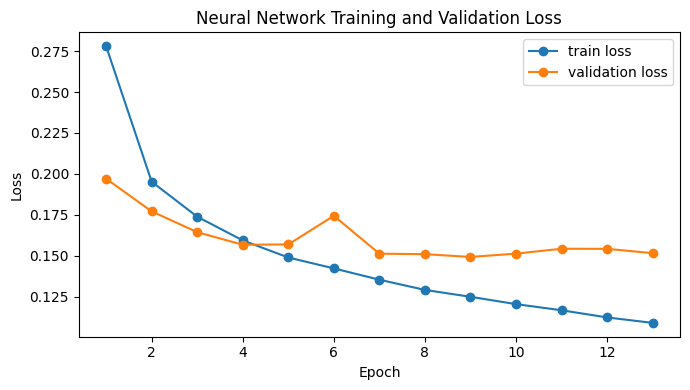

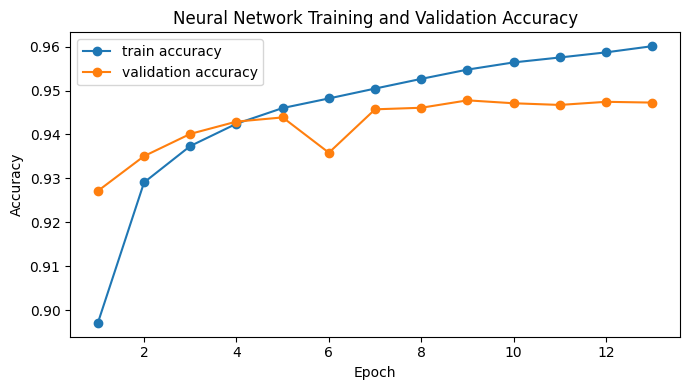

In [17]:
history_df = pd.DataFrame(history)
history_df.to_csv(NN_OUTPUT_DIR / "nn_training_history.csv", index=False)

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural Network Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig(NN_OUTPUT_DIR / "nn_loss_curve.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_accuracy"], marker="o", label="train accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Neural Network Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(NN_OUTPUT_DIR / "nn_accuracy_curve.png", dpi=150)
plt.show()

## Validation evaluation

In [18]:
val_loss, val_accuracy, val_true_encoded, val_pred_encoded = run_one_epoch(model, val_loader, criterion)

val_true = label_encoder.inverse_transform(val_true_encoded)
val_pred = label_encoder.inverse_transform(val_pred_encoded)

print("Validation loss:", val_loss)
print("Validation accuracy:", val_accuracy)
print(classification_report(val_true, val_pred))

Validation loss: 0.1491982734097375
Validation accuracy: 0.9477777777777778
              precision    recall  f1-score   support

  hackernews       0.93      0.96      0.95     15000
      reddit       0.94      0.94      0.94     15000
     twitter       0.97      0.94      0.95     15000

    accuracy                           0.95     45000
   macro avg       0.95      0.95      0.95     45000
weighted avg       0.95      0.95      0.95     45000



## Test evaluation

With finalized hyperparameters

In [19]:
test_loss, test_accuracy, test_true_encoded, test_pred_encoded = run_one_epoch(model, test_loader, criterion)

test_true = label_encoder.inverse_transform(test_true_encoded)
test_pred = label_encoder.inverse_transform(test_pred_encoded)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)
print(classification_report(test_true, test_pred))

Test loss: 0.1480088874643711
Test accuracy: 0.946623408368703
              precision    recall  f1-score   support

  hackernews       0.93      0.96      0.94     15000
      reddit       0.94      0.94      0.94     15000
     twitter       0.97      0.94      0.95     15001

    accuracy                           0.95     45001
   macro avg       0.95      0.95      0.95     45001
weighted avg       0.95      0.95      0.95     45001



## Confusion matrix

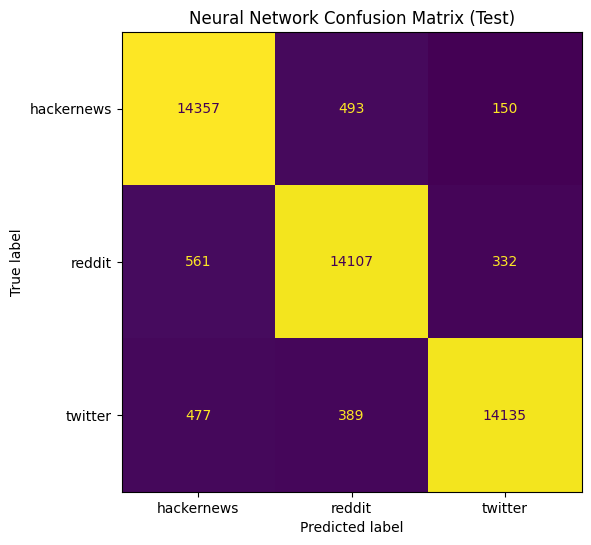

In [20]:
labels = list(label_encoder.classes_)

cm = confusion_matrix(test_true, test_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, colorbar=False)
plt.title("Neural Network Confusion Matrix (Test)")
plt.tight_layout()
plt.savefig(NN_OUTPUT_DIR / "nn_confusion_matrix.png", dpi=150)
plt.show()

## Save model and preprocessing artifacts

Save some file sor the dashboard. The full prediction pipeline needs the sentence embedding model name, embedding scaler, text-stat scaler, label encoder, and PyTorch model weights.

In [21]:
model_path = NN_OUTPUT_DIR / "platform_mlp_state_dict.pt"
torch.save(model.state_dict(), model_path)

preprocessing_bundle = {
    "embedding_model_name": EMBEDDING_MODEL_NAME,
    "normalize_embeddings": NORMALIZE_EMBEDDINGS,
    "embedding_scaler": embedding_scaler,
    "num_scaler": num_scaler,
    "label_encoder": label_encoder,
    "text_stat_cols": TEXT_STAT_COLS,
    "input_dim": input_dim,
    "num_classes": num_classes,
    "hidden_dim": 256,
    "dropout": 0.30,
}

bundle_path = NN_OUTPUT_DIR / "platform_mlp_embedding_preprocessing.joblib"
joblib.dump(preprocessing_bundle, bundle_path)

metrics = {
    "model_type": "MiniLM sentence embeddings + text stats + PyTorch MLP",
    "embedding_model_name": EMBEDDING_MODEL_NAME,
    "normalize_embeddings": bool(NORMALIZE_EMBEDDINGS),
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val_loss),
    "validation_loss": float(val_loss),
    "validation_accuracy": float(val_accuracy),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "classes": list(label_encoder.classes_),
    "embedding_dim": int(X_train_embed.shape[1]),
    "num_text_stat_features": int(len(TEXT_STAT_COLS)),
    "input_dim": int(input_dim),
    "batch_size": int(BATCH_SIZE),
    "learning_rate": float(LEARNING_RATE),
    "weight_decay": float(WEIGHT_DECAY),
}

metrics_path = NN_OUTPUT_DIR / "nn_embedding_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved model to:", model_path)
print("Saved preprocessing bundle to:", bundle_path)
print("Saved metrics to:", metrics_path)


Saved model to: /Users/mhedlund/CIS2450/cis2450-final-project/outputs/modeling/neural_network/platform_mlp_state_dict.pt
Saved preprocessing bundle to: /Users/mhedlund/CIS2450/cis2450-final-project/outputs/modeling/neural_network/platform_mlp_embedding_preprocessing.joblib
Saved metrics to: /Users/mhedlund/CIS2450/cis2450-final-project/outputs/modeling/neural_network/nn_embedding_metrics.json
